# Import Packages

In [64]:
from causaldata import texas
from pysyncon import Dataprep, Synth
from pysyncon.utils import PlaceboTest
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Loading Dataset

In [5]:
df = texas.load_pandas().data
df = pd.DataFrame(df)
df.head()

,statefip,year,bmprison,wmprison,alcohol,income,ur,poverty,black,perc1519,aidscapita,state
0,1,1985,6227.0,4210.0,1.90,11566,8.616667,20.600000,25.866339,8.461768,0.679504,Alabama
1,1,1986,6657.0,4423.0,1.90,12164,9.083334,23.799999,25.827267,8.473580,0.851692,Alabama
2,1,1987,7281.0,4803.0,1.89,12826,7.650000,21.299999,25.777328,8.397089,1.967214,Alabama
3,1,1988,7244.0,4605.0,1.89,13698,6.916667,19.299999,25.734392,8.280076,2.758137,Alabama
4,1,1989,8056.0,4998.0,1.87,14865,6.616667,18.900000,25.694050,8.088959,3.845907,Alabama


In [8]:
df.shape

(816, 12)

In [6]:
df.describe()

,statefip,year,bmprison,wmprison,alcohol,income,ur,poverty,black,perc1519,aidscapita
count,816.000000,816.000000,816.000000,802.000000,816.000000,816.000000,816.000000,816.000000,816.000000,816.000000,816.000000
mean,28.960784,1992.500000,7625.753064,6324.305486,2.388370,20626.337010,5.545997,13.061642,11.832163,7.346907,7.967292
std,15.686450,4.612599,10088.113663,7984.170136,0.595352,5357.388816,1.776836,4.104095,12.638289,0.746343,12.240249
min,1.000000,1985.000000,0.000000,76.000000,1.200000,9892.000000,2.258333,2.900000,0.222412,5.136729,0.000000
25%,16.000000,1988.750000,489.500000,1733.750000,2.040000,16613.250000,4.316667,10.100000,3.254317,6.836827,2.077074
50%,29.000000,1992.500000,3055.500000,4175.500000,2.300000,20060.000000,5.312500,12.400000,8.016722,7.346298,4.489840
75%,42.000000,1996.250000,11423.750000,7484.500000,2.560000,24064.500000,6.575000,15.425000,16.719257,7.834375,9.434502
max,56.000000,2000.000000,61861.000000,74992.000000,5.050000,41489.000000,13.441667,27.200001,71.346375,10.419608,121.173241


In [25]:
states = df["state"].unique().tolist()
predictors = [x for x in states if x != "Texas"]
print(predictors)

['Alabama', 'Alaska', 'Arizona', 'Arkansas', 'California', 'Colorado', 'Connecticut', 'Delaware', 'District of Columbia', 'Florida', 'Georgia', 'Hawaii', 'Idaho', 'Illinois', 'Indiana', 'Iowa', 'Kansas', 'Kentucky', 'Louisiana', 'Maine', 'Maryland', 'Massachusetts', 'Michigan', 'Minnesota', 'Mississippi', 'Missouri', 'Montana', 'Nebraska', 'Nevada', 'New Hampshire', 'New Jersey', 'New Mexico', 'New York', 'North Carolina', 'North Dakota', 'Ohio', 'Oklahoma', 'Oregon', 'Pennsylvania', 'Rhode Island', 'South Carolina', 'South Dakota', 'Tennessee', 'Utah', 'Vermont', 'Virginia', 'Washington', 'West Virginia', 'Wisconsin', 'Wyoming']


In [27]:
final_df = df.pivot(
    index = "year",
    columns = "state",
    values = ["bmprison", "wmprison", "alcohol", "income", "ur", "poverty", "black", "perc1519", "aidscapita"]
).reset_index()
final_df.head()

year bmprison                                                          \
state        Alabama Alaska Arizona Arkansas California Colorado Connecticut   
0      1985   6227.0  198.0  1297.0   2153.0    16138.0    665.0      2620.0   
1      1986   6657.0  211.0  1452.0   2238.0    19549.0    786.0      2890.0   
2      1987   7281.0  217.0  1675.0   2536.0    22184.0    959.0      3070.0   
3      1988   7244.0  271.0  1775.0   2646.0    26438.0   1229.0      3541.0   
4      1989   8056.0  310.0  2033.0   3126.0    30066.0   1492.0      4172.0   

                                     ...   aidscapita                       \
state Delaware District of Columbia  ... South Dakota Tennessee      Texas   
0       1356.0               6021.0  ...     0.000000  0.572468   2.580350   
1       1545.0               6241.0  ...     0.000000  1.371498   5.035212   
2       1595.0               7126.0  ...     0.000000  1.818706   7.458986   
3       1823.0               8205.0  ...     0.572848  2.467257   9.046394   
4       2045.0               9320.0  ...     0.000000  3.131134  11.370119   

                                                                        \
state      Utah   Vermont  Virginia Washington West Virginia Wisconsin   
0      0.730226  0.000000  1.416917   1.863143      0.209715  0.400088   
1      1.503232  0.000000  2.632287   2.919190      0.531169  0.798945   
2      1.906636  0.000000  3.792269   4.147779      0.807370  1.297443   
3      2.604128  0.727480  4.985286   5.214800      0.819433  1.306185   
4      2.696524  1.793085  5.865663   6.615520      2.103369  2.038428   

                 
state   Wyoming  
0      0.000000  
1      0.000000  
2      0.000000  
3      0.000000  
4      0.872576  

[5 rows x 460 columns]

In [32]:
variables = ["bmprison", "wmprison", "income", "ur", "poverty", "black", "perc1519", "alcohol", "aidscapita"]

fig = make_subplots(rows=len(variables), cols=1, subplot_titles=variables)
fig.update_layout(height=300 * len(variables))

for i, var in enumerate(variables, 1):
    for state in final_df[var].columns:
        fig.add_trace(
            go.Scatter(x=final_df["year"], y=final_df[var][state], name=state, showlegend=False,
                       line=dict(color="red" if state == "Texas" else "lightgrey")),
            row=i, col=1
        )

fig.show()

# Assumption Testing

## Convex Hull Assumption Testing

In [34]:
final_df.dtypes

            state        
year                           int16
bmprison    Alabama          float64
            Alaska           float64
            Arizona          float64
            Arkansas         float64
                              ...   
aidscapita  Virginia         float64
            Washington       float64
            West Virginia    float64
            Wisconsin        float64
            Wyoming          float64
Length: 460, dtype: object

In [47]:
treatment_year = 1993
final_df_pre_treatment = final_df[final_df["year"] < 1993]
for variable in variables:
    texas_value = final_df_pre_treatment[variable]["Texas"].mean()
    donor_min = final_df_pre_treatment[variable][[x for x in states if x != "Texas"]].min().min()
    donor_max = final_df_pre_treatment[variable][[x for x in states if x!= "Texas"]].max().max()
    
    if (texas_value < donor_min) or (texas_value > donor_max):
        print(f"Texas outside convex hull on this predictor {variable}.")
    else:
        print(f"Variable {variable} passes convex hull test.")

Variable bmprison passes convex hull test.
Variable wmprison passes convex hull test.
Variable income passes convex hull test.
Variable ur passes convex hull test.
Variable poverty passes convex hull test.
Variable black passes convex hull test.
Variable perc1519 passes convex hull test.
Variable alcohol passes convex hull test.
Variable aidscapita passes convex hull test.


## Pre-Treatment Fit Assumption Test

In [56]:
control_states = predictors.copy()

dataprep = Dataprep(
    foo = df,
    predictors = variables,
    predictors_op = "mean",
    dependent = "bmprison",
    unit_variable = "state",
    time_variable = "year",
    treatment_identifier = "Texas",
    controls_identifier = control_states,
    time_predictors_prior = range(1985, 1993),
    time_optimize_ssr = range(1985,1993),
    special_predictors=[
        ("bmprison", range(1985, 1990), "mean"),
        ("bmprison", range(1990, 1993), "mean"),
    ],)
synth = Synth()
synth.fit(dataprep = dataprep)

In [61]:
print(synth.weights(threshold = 0.01), "\n")
print(synth.summary(), "\n")
print(np.sqrt(synth.mspe()), "\n")

California    0.060
Florida       0.210
Louisiana     0.307
New York      0.422
Name: weights, dtype: float64 

                        V    treated  synthetic  sample mean
bmprison            0.202  19448.500  19157.760     5303.636
wmprison            0.032  14017.286  16865.875     5249.342
income              0.001  16108.625  18148.373    17080.345
ur                  0.072      7.426      7.145        6.153
poverty             0.099     17.200     16.593       13.392
black               0.032     16.020     21.508       11.412
perc1519            0.000      7.880      7.278        7.467
alcohol             0.109      2.511      2.535        2.517
aidscapita          0.000     10.048     19.345        6.620
special.1.bmprison  0.132  16427.400  16665.297     4559.744
special.2.bmprison  0.321  24483.667  23311.864     6543.457 

1152.0995731237804 



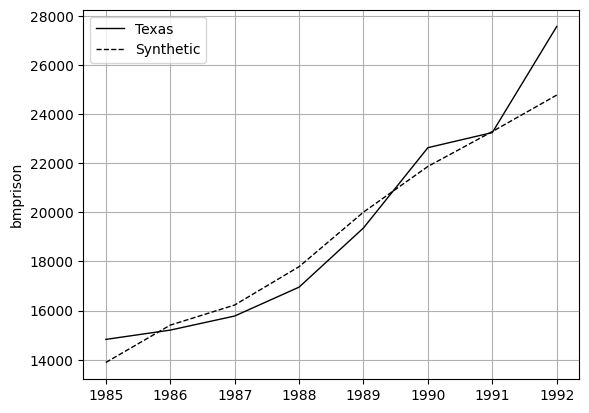

In [62]:
synth.path_plot()

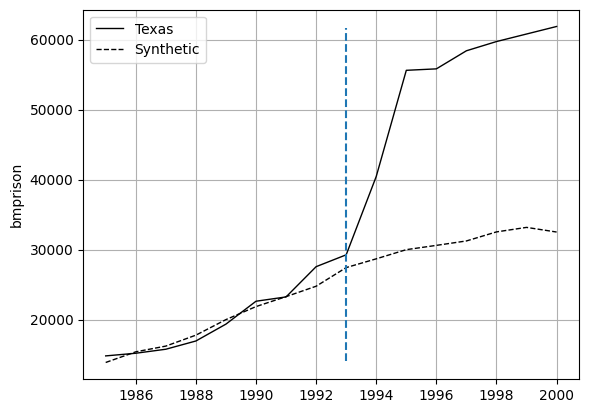

In [63]:
synth.path_plot(
    time_period=range(1985, 2001),
    treatment_time=1993,
)

# Validation: Placebo Test

In [65]:
placebo = PlaceboTest()
placebo.fit(dataprep=dataprep, scm=Synth(), verbose=True)

(1/50) Completed placebo test for District of Columbia.
(2/50) Completed placebo test for California.
(3/50) Completed placebo test for Hawaii.
(4/50) Completed placebo test for Arkansas.
(5/50) Completed placebo test for Connecticut.
(6/50) Completed placebo test for Florida.
(7/50) Completed placebo test for Idaho.
(8/50) Completed placebo test for Alaska.
(9/50) Completed placebo test for Illinois.
(10/50) Completed placebo test for Louisiana.
(11/50) Completed placebo test for Arizona.
(12/50) Completed placebo test for Georgia.
(13/50) Completed placebo test for Kansas.
(14/50) Completed placebo test for Kentucky.
(15/50) Completed placebo test for Delaware.
(16/50) Completed placebo test for Maryland.
(17/50) Completed placebo test for Iowa.
(18/50) Completed placebo test for Michigan.
(19/50) Completed placebo test for Mississippi.
(20/50) Completed placebo test for Colorado.
(21/50) Completed placebo test for Nevada.
(22/50) Completed placebo test for Massachusetts.
(23/50) Com

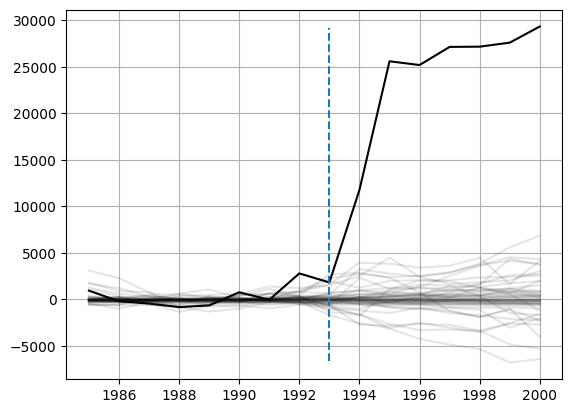

0.0


In [66]:
# Gaps plot — Texas in bold, all placebos in grey
placebo.gaps_plot(
    time_period=range(1985, 2001),
    treatment_time=1993,
    mspe_threshold=5,  # drop donors with poor pre-fit (>5x Texas's pre-RMSPE)
)

# p-value
print(placebo.pvalue(treatment_time=1993))
